In [ ]:
! pip install langchain langchain_core langchain_mistralai langchain_community
# so essential packages at start

In [ ]:
import os
import dotenv
from google.colab import userdata
from dotenv import load_dotenv
secret_key = userdata.get("MISTRAL_API_KEY")
os.environ["MISTRAL_API_KEY"] = secret_key
with open(".env", "w") as f: # so in colab also .env required
    f.write(f"MISTRAL_API_KEY={secret_key}\n")
load_dotenv() # to load the mistrial api key

In [ ]:
# create and normal llm app and do some question answering
from langchain_mistralai import ChatMistralAI
llm = ChatMistralAI(
    model="mistral-small-latest",
    temperature=0.2 # so this is the reasoning ability
)

message = input("enter question:")
outputs = llm.invoke(message)
print(outputs.content)
# normal llm qna

In [ ]:
## Understanding chatTemplates and how it is helpful
from langchain_core.prompts import ChatPromptTemplate, HumanMessagePromptTemplate
# an template is created
template = ChatPromptTemplate(
    messages=[ # so it consist the messgaes of system , human , assistant (ai)
        ("system","so u are and model which specialize in geography question with giving detailed answer"), # so this is the ....
        ("human","{human_input}")
    ]
)
# lets invoke the template to fit it
message = input("============\nenter question related to geography:")
prompt = template.invoke(
    {"human_input":message}
)

output = llm.invoke(prompt)
print(f"==========\nLLM Output:\n{output.content}")
# so this output is detailed because of the system prompt it added

In [ ]:
# now lets move to embeddings model (embeddings of text)
from langchain_mistralai import MistralAIEmbeddings

embeddings = MistralAIEmbeddings(
    model="mistral-embed",
)

text = """
Maharashtra[a] is a state in the western peninsular region of India occupying a substantial portion of the Deccan Plateau. It is bordered by the Arabian Sea to the west, the Indian states of Karnataka and Goa to the south, Telangana to the southeast and Chhattisgarh to the east, Gujarat and Madhya Pradesh to the north, and the Indian union territory of Dadra and Nagar Haveli and Daman and Diu to the northwest.[20] Maharashtra is the second-most populous state in India, the third-most populous country subdivision in South Asia, and the fourth-most populous in the world.
""" # so and proper article from wikipedia https://en.wikipedia.org/wiki/Maharashtra

single_vector = embeddings.embed_query(text)
print(f"Embeddings of text:\n vector length :{len(single_vector)}\nvector:{single_vector}")
# so first tokenizer initialized (which is seperate part to explain but great) then the tokenized embedded the text by creating and single 1D vector a
# and the vector length ==  embedding dim
# as the tokenizer may be  trained on different text to the unknown words are treated with special token like (<unk>)

In [ ]:
# lets try the embedding of the documnet
### -> so this is done on the chunks >>> so lets look later

In [ ]:
# so now we will move to chuncking of text (document loader)
## 1. text file
from langchain_community.document_loaders import TextLoader # to load the text file
FILE_PATH = "/content/document.txt"
print(f'[INFO] FILE Path : {FILE_PATH}')
loader = TextLoader(FILE_PATH,encoding="utf-8")
documents =  loader.load() # to load the documents
print(f"[INFO] Length:{len(documents)}") # always the length is 1 because only one page

In [ ]:
! pip install pypdf # to load the pdf

In [ ]:
## 2. PDF files
from langchain_community.document_loaders import PyPDFLoader # pypdf is essential
FILE_PATH = "/content/Anti_Sycophancy_DPO_Research_Draft.pdf"
print(f'[INFO] FILE Path : {FILE_PATH}')
loader = PyPDFLoader(FILE_PATH)
documents =  loader.load() # to load the documents
print(f"[INFO] Length:{len(documents)}") # always the length is decided by pages

In [ ]:
documents.__len__() # the length pages in the list
print(f"===========\nPage1:\n{documents[0].page_content}") # example
print(f"===========\nPage2:\n{documents[1].page_content}")

In [ ]:
# So now we move for the text splitter
## so their are three types of text splitter
## 1. Recursive text splitter
## 2. Character text splitter (internally BPE)
## 3. Semantic text splitter (in build) >>> future
! pip install -U langchain-text-splitters

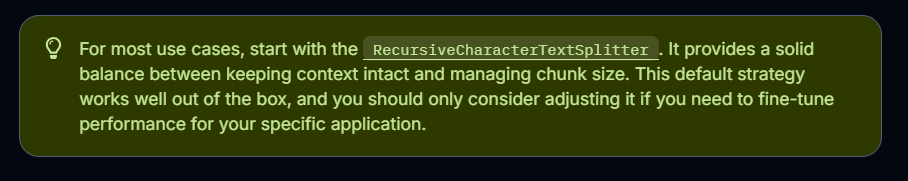

In [ ]:
from langchain_text_splitters import RecursiveCharacterTextSplitter
## 2. Documents (pdf/text)
text_splitter = RecursiveCharacterTextSplitter(chunk_size=100, chunk_overlap=0)
# chunk size = it means that one token will consist of that length character
# chunk overlap = it means that the to capture some semantic or similar to this we make it
texts = text_splitter.split_documents(documents) # Split the loaded PDF documents

In [ ]:
print(f'[INFO] Total Length of splitted documents :{len(texts)}') # so total 115 cheunks of individual chunk length 100 are formed
print(f'[INFO] Sample :\n{texts[0]}')


In [ ]:
## So after the splitting of documents we proceed with embedding of that documents
### Embedding of documents
embeddings = MistralAIEmbeddings(
    model="mistral-embed",
)

embedding_text = embeddings.embed_documents([doc.page_content for doc in texts]) # the splitted docs document by document

In [ ]:
print(f'[INFO] length of embeding:{len(embedding_text)}') # so individual embeddings for each document(class) in documents

In [ ]:
## comming to vector store
## Since colab is facing issuse related to chromaDB so moving with InMemroyStorage()
from langchain_core.vectorstores import InMemoryVectorStore
vector_store = InMemoryVectorStore(embedding=embeddings)

In [ ]:
vector_store.add_documents(
    documents = documents
)

In [ ]:
# Search for relevant documents
query = "what is research topic"
matched_docs = vector_store.similarity_search(query, k=2) # k is the number od matched output we want

# Print the matching text chunks
for i, doc in enumerate(matched_docs):
    print(f"Match {i+1}:\n{doc.page_content}\n")

In [ ]:
retriver = vector_store.as_retriever(search_type="similarity", search_kwargs={"k": 2})
# this is the retirver more optimized than the normal similaraty search

In [ ]:
## now searching with **retriver**
query = "what is research topic"
matched_docs = retriver.invoke(query)
for doc in matched_docs:
  print("*"*40)
  print(doc.page_content)

In [ ]:
# ## introducing **MultiQueryRetriver** to get more ran
#  it solves the main flaw of standard vector searches: getting trapped by exact phrasing.
#  Instead of embedding a user's question only once, it uses an LLM to generate \(3\) to \(5\) variations of the query,
#  searches the database for all of them, and then merges the results.

In [ ]:
from langchain_classic.retrievers.multi_query import MultiQueryRetriever
multi_query = MultiQueryRetriever.from_llm(
    retriever = retriver, # the retriver to pull
    llm = llm # the llm use to generate the variation of retriver
)

In [ ]:
query = "what is research topic"
matched_docs = multi_query.invoke(query)
for doc in matched_docs:
  print("*"*40)
  print(doc.page_content)

# so this is very great from previous one as it correctly picked the second and third in their order

In [ ]:
## rag notebook done !!
## >> next streamlit application